<a href="https://www.kaggle.com/code/vedikagupta0/performing-eda?scriptVersionId=304445557" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [186]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
df_og = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
tf = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [187]:
df_og.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [188]:
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [189]:
id_col = ['id', 'customerID']

In [190]:
df_og.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [191]:
df2.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [192]:
df_og.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [193]:
df2.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [194]:
df2.shape

(7043, 21)

In [195]:
df_og.shape

(594194, 21)

In [196]:
df = pd.concat([df_og, df2], axis=0)

In [197]:
df.drop(columns=id_col, inplace=True)

In [198]:
df.shape

(601237, 20)

#### 1. No null values are observed.
#### 2. Imbalance is observed in PhoneService, SeniorCitizen and Dependents.
#### SOL: added rarity factor.
#### 3. TotalCharges is skewed probably.
#### SOL: log can be used.
#### 4. Churn i.e. Target column is facing major imbalance.
#### SOL: we can use stratified splitting
#### 5. StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity and InternetService has some weird pattern for NO/ No internet, which can be a useful insight for our modeling.
#### SOL: added something for them.

In [199]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0).astype(float)

In [200]:
cat_cols = df.describe(include='object').columns[:-1]

In [201]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    df_og[col] = le.transform(df_og[col])
    tf[col] = le.transform(tf[col])
    
    encoders[col] = le
    
    # mapping: original -> encoded
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} mapping:")
    print(mapping)
    print("-" * 40)

gender mapping:
{'Female': np.int64(0), 'Male': np.int64(1)}
----------------------------------------
Partner mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
Dependents mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
PhoneService mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}
----------------------------------------
MultipleLines mapping:
{'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
InternetService mapping:
{'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
----------------------------------------
OnlineSecurity mapping:
{'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
OnlineBackup mapping:
{'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
----------------------------------------
DeviceProtection mapping:
{'No': np.int64(0),

In [202]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
df_og['Churn'] = df_og['Churn'].map({'No':0, 'Yes':1})

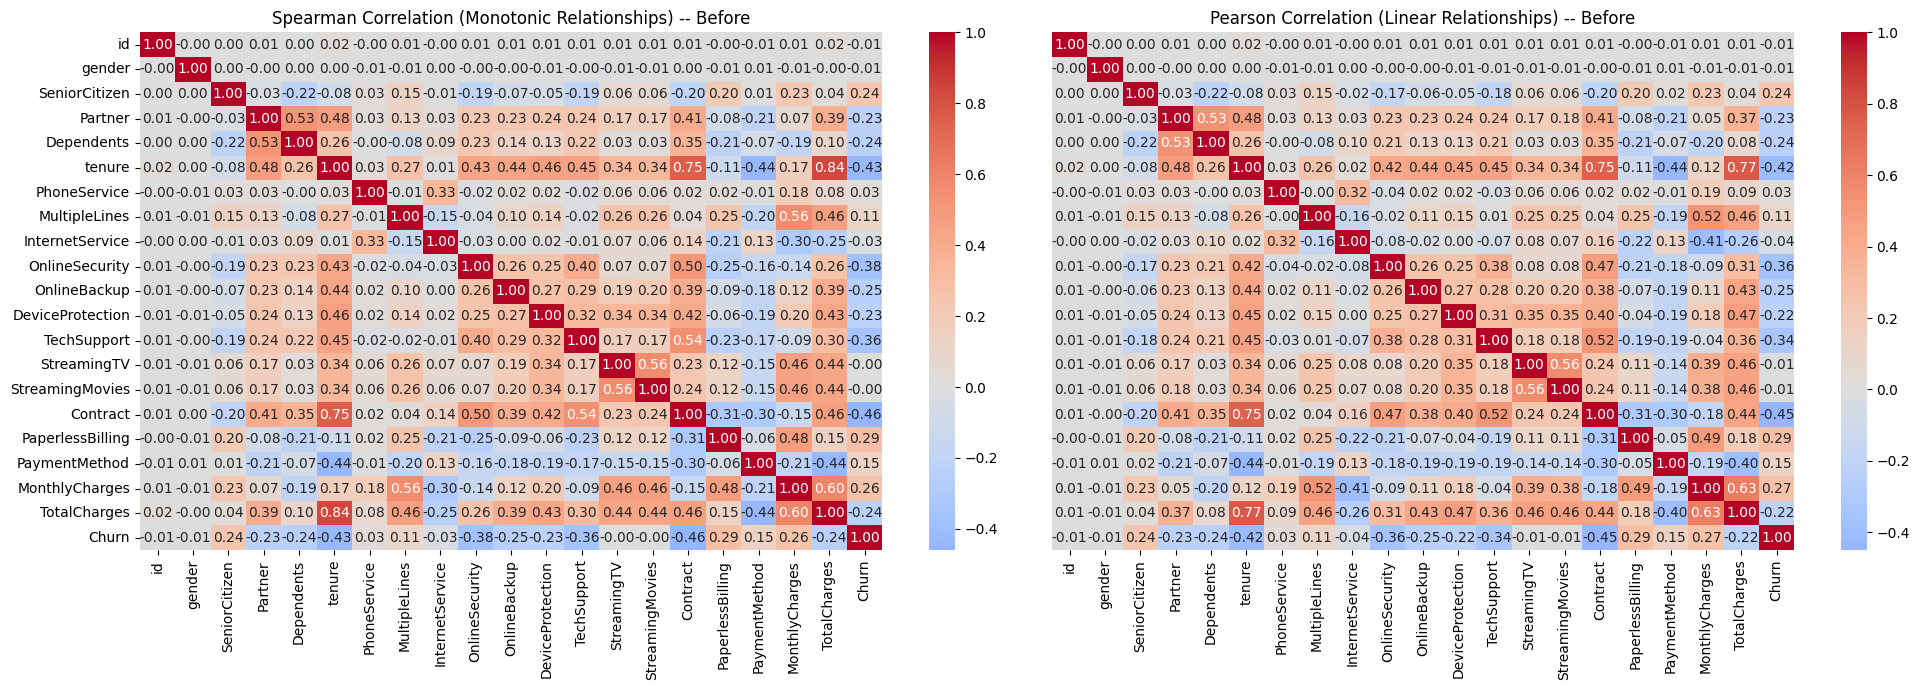

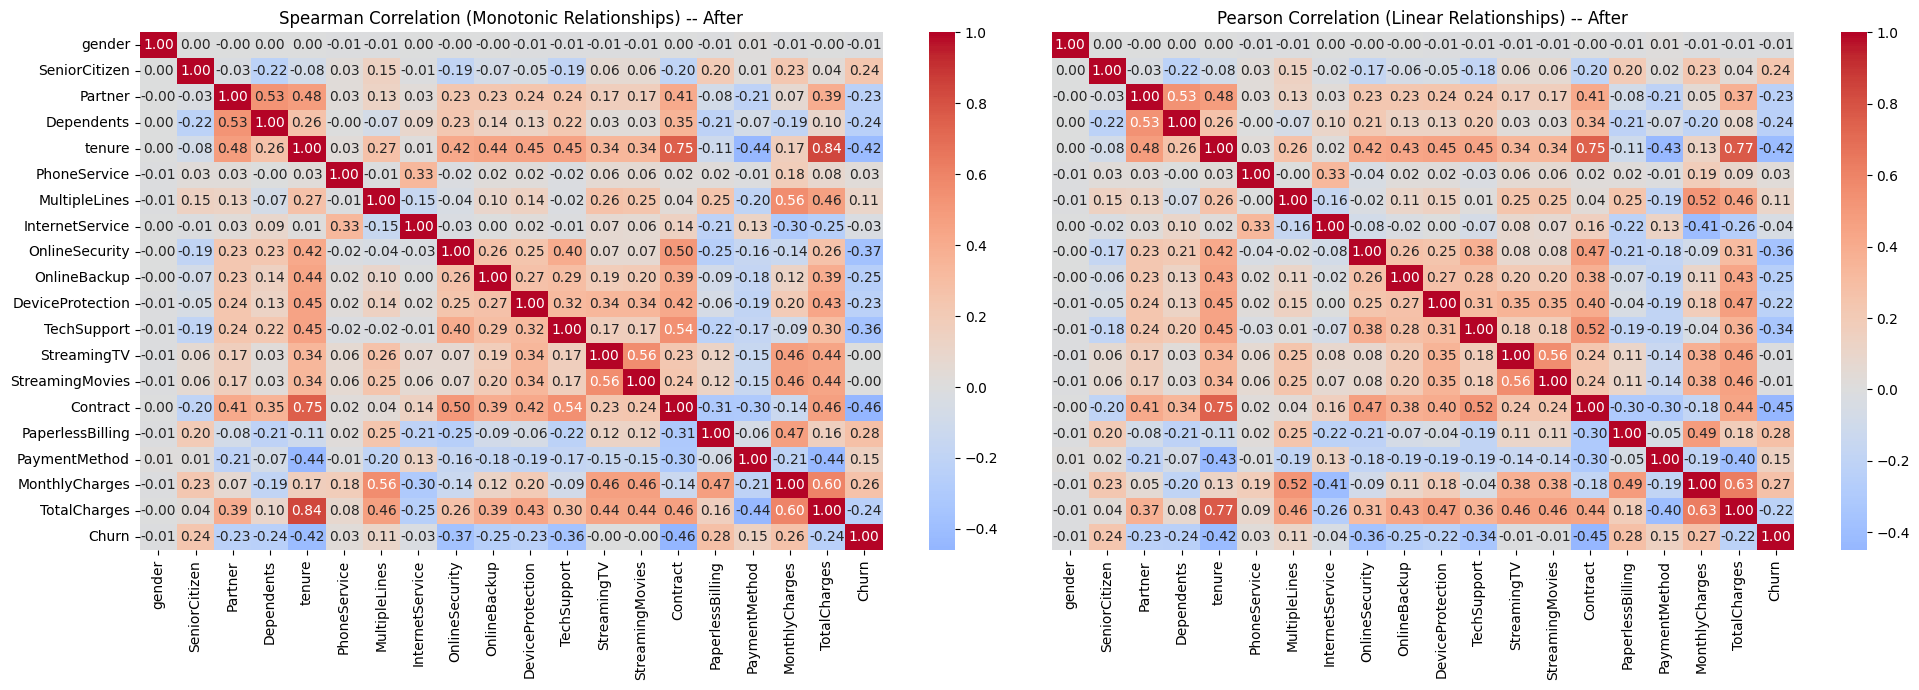

In [203]:
# correlations
spearman_corr = df_og.corr(method="spearman")
kendall_corr  = df_og.corr(method="pearson")

# one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Spearman
sns.heatmap(
    spearman_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- Before")

# Pearson
sns.heatmap(
    kendall_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    yticklabels=False
)
axes[1].set_title("Pearson Correlation (Linear Relationships) -- Before")

plt.tight_layout()
plt.show()
# correlations
spearman_corr = df.corr(method="spearman")
kendall_corr  = df.corr(method="pearson")

# one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Spearman
sns.heatmap(
    spearman_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- After")

# Pearson
sns.heatmap(
    kendall_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    yticklabels=False
)
axes[1].set_title("Pearson Correlation (Linear Relationships) -- After")

plt.tight_layout()
plt.show()

In [204]:
cols = ['StreamingMovies', 'StreamingTV', 'TechSupport',
        'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']

mask = (df[cols] == 1).all(axis=1)
filtered_df = df[mask]
filtered_df.shape

(142253, 20)

In [205]:
100 - ((df.shape[0] - 140727)/ df.shape[0])*100

23.40624412669213

#### Even after being a synthetic dataset, these 6 columns possess same value conveys an important detail.

In [206]:
df.duplicated().sum()

np.int64(22)

In [207]:
df.drop_duplicates(inplace=True)

In [208]:
df['dominance_of_nointernetservice'] = (df[cols] == 1).all(axis=1)

In [209]:
df.dominance_of_nointernetservice.value_counts()

dominance_of_nointernetservice
False    458976
True     142239
Name: count, dtype: int64

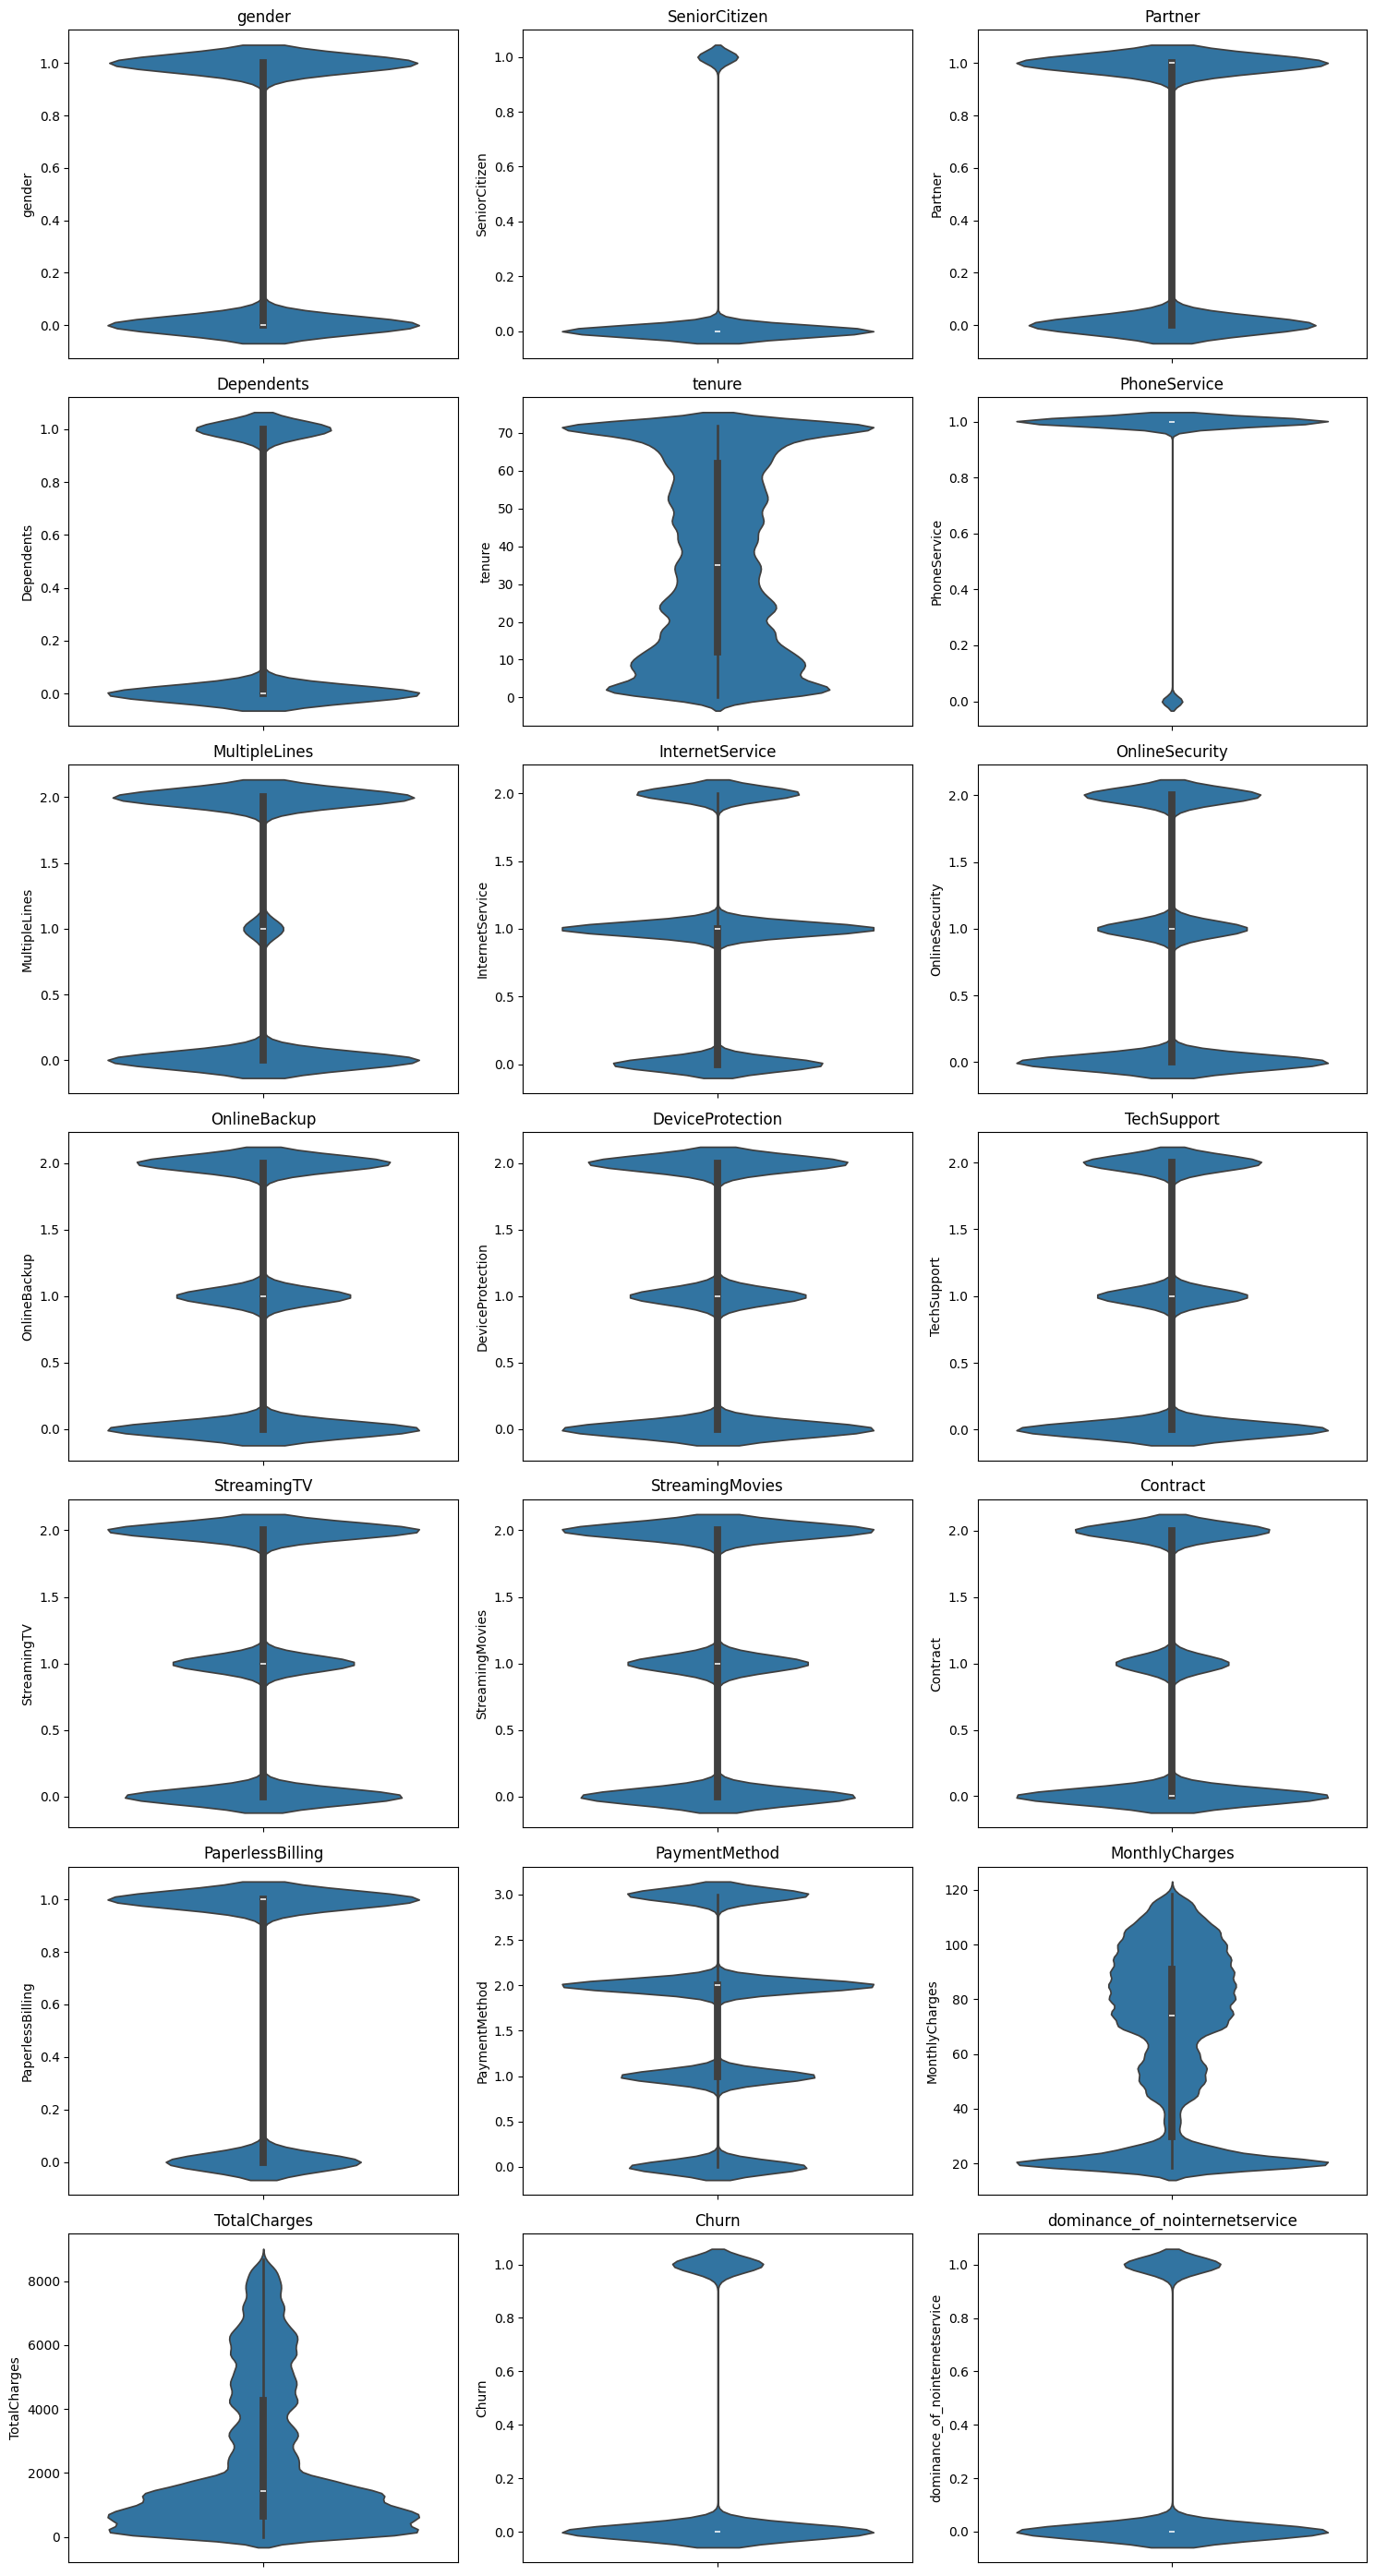

In [211]:
import math
n = len(df.columns)
ncols = 3
nrows = math.ceil(n / ncols)

# violin plots in grid
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.violinplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# remove empty axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [212]:
pd.crosstab(df['Churn'], df['dominance_of_nointernetservice'])


dominance_of_nointernetservice,False,True
Churn,,
0,325425,140116
1,133551,2123


In [221]:
cols = ['dominance_of_nointernetservice', 'PaperlessBilling',
        'PhoneService', 'Dependents', 'SeniorCitizen']

pattern_map = {
    'dominance_of_nointernetservice': 1,
    'PaperlessBilling': 0,
    'PhoneService': 0,
    'Dependents': 1,
    'SeniorCitizen': 1
}

# count matches
df['rarity_raw'] = sum((df[col] == val).astype(int) for col, val in pattern_map.items())

# scale to 0–5 (already 0–len(cols), so normalize)
df['rarity_factor'] = 5 * df['rarity_raw'] / len(cols)

In [222]:
df.rarity_factor.value_counts()

rarity_factor
1.0    210985
0.0    197547
2.0    127535
3.0     65068
4.0        80
Name: count, dtype: int64

In [223]:
cols = ['TotalCharges', 'MonthlyCharges', 'tenure']

def add_features(d):
    # log transform (handle zeros)
    for c in cols:
        d[f'{c}_log'] = np.log1p(d[c])
    
    # row-wise variance across the three columns
    d['charges_tenure_var'] = d[cols].var(axis=1)
    
    return d

df_og = add_features(df_og)
df    = add_features(df)
tf    = add_features(tf)